In [21]:
import sys
#Chech version is 3.11.9import sys
print(sys.version)

3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]


In [4]:
!python -m pip install qiskit[visualization] qiskit-aer

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
   -------------------- ------------------- 4.7/9.1 MB 28.6 MB/s eta 0:00:01
   ---------------------------------------- 9.1/9.1 MB 33.4 MB/s  0:00:00
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ------------------------------- -------- 7.6/9.6 MB 39.0 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 39.6 MB/s  0:00:00
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 2.1/2.1 MB 38.1 MB/s  0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136929 s

In [22]:
import qiskit
print(qiskit.__version__)
# Book p.52 references qiskit.__qiskit_version__, but that attribute was removed in Qiskit 1.0
# print(qiskit.__qiskit_version__)  # AttributeError on Qiskit >= 1.0

2.4.1


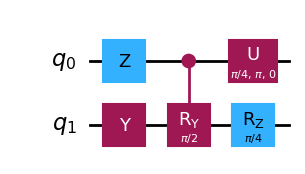

In [23]:
import numpy as np

from qiskit import *

qc  = QuantumCircuit(2)
qc.z(0)
qc.y(1)
qc.cry(np.pi/2,0,1)
qc.u(np.pi/4, np.pi, 0, 0)
qc.rz(np.pi/4, 1)

qc.draw('mpl')

In [24]:
for qbit in qc.qubits:
    print(qbit)

print(qc.num_qubits)

bits_0 = ClassicalRegister(qc.num_qubits)
print(bits_0)

<Qubit register=(2, "q"), index=0>
<Qubit register=(2, "q"), index=1>
2
ClassicalRegister(2, 'c0')


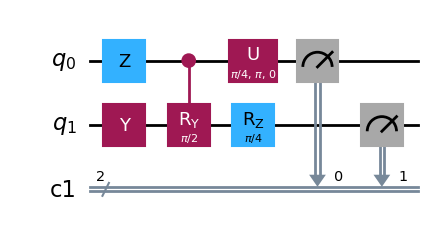

In [6]:
def measure_all(qc):
    """Add a measurement to all qubits in the circuit."""
    bits = ClassicalRegister(qc.num_qubits)
    qc.add_register(bits)
    for qbit in range(qc.num_qubits):
        qc.measure(qbit, bits[qbit])

measure_all(qc)
qc.draw('mpl')

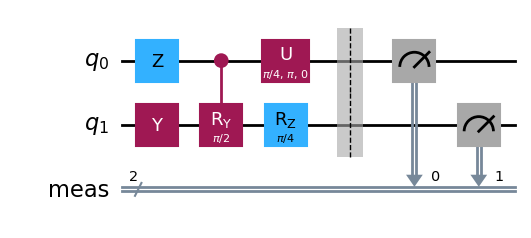

In [25]:
qc.measure_all()
qc.draw('mpl')

In [37]:
!python -m pip install qiskit-aer-gpu

ERROR: Could not find a version that satisfies the requirement qiskit-aer-gpu (from versions: none)
ERROR: No matching distribution found for qiskit-aer-gpu


In [26]:
#from qiskit.providers.aer import AerSimulator <- outdated (Book pg 58)

from qiskit_aer import AerSimulator

sim = AerSimulator()

# 'statevector' forces the simulator to calculate the exact mathematical wave function 
# using pure matrix multiplication, which allows the GPU to optimize the linear algebra.

sim = AerSimulator(method = 'statevector', device = 'CPU')
# sim_gpu = AerSimulator(method='thrust', device='GPU')

In [27]:
hadamard_qc = QuantumCircuit(2, 2)
hadamard_qc.h(0)
hadamard_qc.measure(range(2), range(2))

job = sim.run(hadamard_qc, shots=1024)

result = job.result()
counts = result.get_counts()
print(counts)

#Use seed_transpiler and seed_simulator to make the results reproducible

{'00': 499, '01': 525}


In [ ]:
#Remarque sur l'ordre Qiskit : le qbit le + à droite est le premier du circuit
#qn ... q0 [<- Ecriture en ligne]
#         q0  [CIRCUIT]
#          .
#          .
#         qn
#

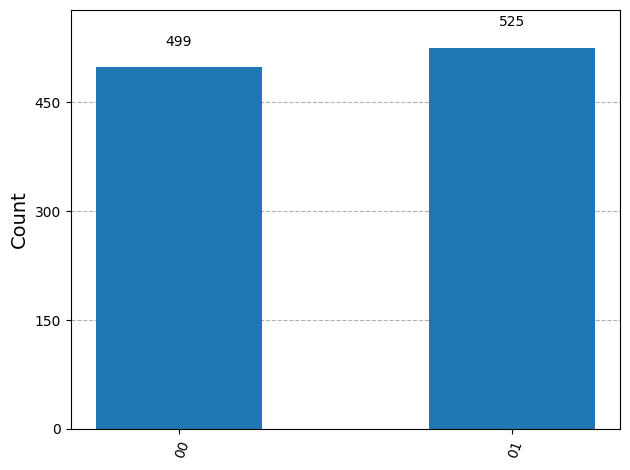

In [28]:
from qiskit.visualization import plot_histogram
plot_histogram(counts)

In [29]:
qc = QuantumCircuit(2, 2)
qc.h(0)

qc.save_statevector()
qc.measure(0, 0)
qc.measure(1, 1)

job = sim.run(qc, shots=1024)

result = job.result()
sv = result.get_statevector()
counts = result.get_counts()

print("Statevector:", sv)
print("Counts:", counts)

Statevector: Statevector([0.70710678+0.j, 0.70710678+0.j, 0.        +0.j,
             0.        +0.j],
            dims=(2, 2))
Counts: {'01': 493, '00': 531}


In [30]:
from qiskit.visualization import array_to_latex
display(array_to_latex(sv, prefix="\\text{Statevector } |\\psi\\rangle = "))

# Method 2: The elegant Quantum Ket notation output
print("\nKet Notation:")
display(sv.draw('latex'))

# Method 3: The clean, text-based alternative (if you don't want math symbols)
print("\nText-based Dirac Notation:")
print(sv.draw('text'))

<IPython.core.display.Latex object>


Ket Notation:


<IPython.core.display.Latex object>


Text-based Dirac Notation:
[0.70710678+0.j,0.70710678+0.j,0.        +0.j,0.        +0.j]


In [31]:
sim_u = AerSimulator(method='unitary')
qc = QuantumCircuit(1)

qc.h(0)
qc.save_unitary()

job = sim_u.run(qc, shots=1024)

result = job.result()

U = result.get_unitary(decimals = 4)
print(U)

display(array_to_latex(U, prefix="\\text{Hadamard Unitary } U = "))

Operator([[ 0.7071+0.j,  0.7071-0.j],
          [ 0.7071+0.j, -0.7071+0.j]],
         input_dims=(2,), output_dims=(2,))


<IPython.core.display.Latex object>

In [32]:
sim_u = AerSimulator(method='unitary')
qc = QuantumCircuit(2)

qc.h(0)
qc.save_unitary()

job = sim_u.run(qc, shots=1024)

result = job.result()

U = result.get_unitary(decimals = 4)
print(U)

display(array_to_latex(U, prefix="\\text{Hadamard Unitary } U = "))

Operator([[ 0.7071+0.j,  0.7071-0.j,  0.    +0.j,  0.    +0.j],
          [ 0.7071+0.j, -0.7071+0.j,  0.    +0.j,  0.    +0.j],
          [ 0.    +0.j,  0.    +0.j,  0.7071+0.j,  0.7071-0.j],
          [ 0.    +0.j,  0.    +0.j,  0.7071+0.j, -0.7071+0.j]],
         input_dims=(2, 2), output_dims=(2, 2))


<IPython.core.display.Latex object>

In [28]:
!python -m pip install qiskit-ibm-runtime

   ---------------------------------------- 0.0/1.9 MB ? eta -:--:--
   ---------------------------------------- 1.9/1.9 MB 15.0 MB/s  0:00:00
   ---------------------------------------- 0.0/540.8 kB ? eta -:--:--
   ---------------------------------------- 540.8/540.8 kB ?  0:00:00

   --- ------------------------------------  1/11 [PyJWT]
   ------- --------------------------------  2/11 [pybase64]
   -------------- -------------------------  4/11 [ibm_cloud_sdk_core]
   -------------- -------------------------  4/11 [ibm_cloud_sdk_core]
   -------------- -------------------------  4/11 [ibm_cloud_sdk_core]
   ------------------ ---------------------  5/11 [samplomatic]
   ------------------ ---------------------  5/11 [samplomatic]
   ------------------ ---------------------  5/11 [samplomatic]
   ------------------ ---------------------  5/11 [samplomatic]
   ------------------ ---------------------  5/11 [samplomatic]
   ------------------ ---------------------  5/11 [samplomatic]

In [33]:
from qiskit_ibm_runtime import QiskitRuntimeService


QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform", 
    token="0rJHinIMu4ESQDyQrNNttIbu08H0L0IGWPoVFGJLRTNz",
    overwrite=True
)

In [34]:
service = QiskitRuntimeService(channel="ibm_quantum_platform")
backends = service.backends(simulator = False)
print(backends)

qiskit_runtime_service.__init__:WARNING:2026-05-26 11:27:41,751: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-05-26 11:27:41,753: Loading instance: open-instance, plan: open


[<IBMBackend('ibm_kingston')>, <IBMBackend('ibm_marrakesh')>, <IBMBackend('ibm_fez')>]


In [35]:
dev = service.backend('ibm_kingston')
dev.n_qubits

qiskit_runtime_service.backends:WARNING:2026-05-26 11:27:44,958: Using instance: open-instance, plan: open


156

In [15]:
dev = service.backend('ibm_marrakesh')
dev.n_qubits

qiskit_runtime_service.backends:WARNING:2026-05-26 11:18:55,150: Using instance: open-instance, plan: open


156

In [16]:
dev = service.backend('ibm_fez')
dev.n_qubits

qiskit_runtime_service.backends:WARNING:2026-05-26 11:18:56,538: Using instance: open-instance, plan: open


156

In [36]:
# job_monitor was removed from qiskit-ibm-runtime entirely -- there is no drop-in replacement.
#
# Old ways (both broken on modern Qiskit):
# from qiskit.providers.ibmq.job import job_monitor   # removed with qiskit-ibmq-provider
# from qiskit_ibm_runtime import job_monitor          # never existed in qiskit-ibm-runtime
#
# Modern approach 1: block until done (simplest)
# result = job.result()  # waits synchronously, raises if job failed
#
# Modern approach 2: poll with status updates
import time

def wait_for_job(job, poll_interval=5):
    """Poll a job until it finishes and return the result."""
    while job.status().name not in ("DONE", "ERROR", "CANCELLED"):
        print(f"Status: {job.status().name}")
        time.sleep(poll_interval)
    print(f"Final status: {job.status().name}")
    return job.result()


In [38]:
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.measure_all()

job = sim.run(qc, shots=1024)
result = job.result()
counts = result.get_counts()
print("Counts:", counts)

Counts: {'11': 494, '00': 530}


In [ ]:
#To run a circuit on a real machine, one should first transpile it : which is kind of the equivalent of compilation

from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler

pm = generate_preset_pass_manager(backend=dev, optimization_level=1)
isa_circuit = pm.run(qc)  # ISA = Instruction Set Architecture

sampler = Sampler(dev)
job = sampler.run([isa_circuit], shots=1024)

transpiled_qc = transpile(qc, dev, optimization_level=3)

print(f"Job submitted to {dev.name} backend ! Job ID: {job.job_id()}")

result = job.result()

Job submitted to ibm_kingston backend ! Job ID: d8ammhtg7okc73eq3cg0


In [53]:
print(json.dumps({
    "metadata": result[0].metadata,
    "counts": result[0].data.meas.get_counts(),
    "num_shots": result[0].data.meas.num_shots,
    "num_bits": result[0].data.meas.num_bits
}, indent=2, cls=DeepEncoder))


{
  "metadata": {
    "circuit_metadata": {}
  },
  "counts": {
    "00": 1849,
    "11": 1838,
    "01": 395,
    "10": 14
  },
  "num_shots": 4096,
  "num_bits": 2
}


In [56]:
spans = result._metadata['execution']['execution_spans']
for i, span in enumerate(spans):
    duration = span.stop - span.start
    print(f"Span {i}:")
    print(f"  Start    : {span.start.strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"  Stop     : {span.stop.strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"  Duration : {duration.total_seconds():.2f}s")


Span 0:
  Start    : 2026-05-26 09:43:39
  Stop     : 2026-05-26 09:43:41
  Duration : 1.88s


In [55]:
print(result[0].metadata)


{'circuit_metadata': {}}


In [ ]:
import json

class DeepEncoder(json.JSONEncoder):
    def default(self, obj):
        if hasattr(obj, '__dict__'):
            return vars(obj)
        if hasattr(obj, '__iter__'):
            return list(obj)
        return repr(obj)

print(json.dumps(vars(result), indent=2, cls=DeepEncoder))


{
  "_pub_results": [
    {}
  ],
  "_metadata": {
    "execution": {
      "execution_spans": {
        "_spans": [
          {
            "_start": "datetime.datetime(2026, 5, 26, 9, 43, 39, 921152)",
            "_stop": "datetime.datetime(2026, 5, 26, 9, 43, 41, 797647)",
            "_data_slices": {
              "0": [
                [
                  4096
                ],
                "slice(0, 1, None)",
                "slice(0, 4096, None)"
              ]
            }
          }
        ]
      }
    },
    "version": 2
  }
}
